# Optimizer Study for Assignment 1

**Topic:** A Controlled Experimental Investigation of Optimization Strategies in Repaired QANet

This notebook implements one structured investigation with two blocks:

1. Scheduler selection for SGD-based methods
2. Main optimization strategy comparison

The goal is to study optimization behavior in a controlled way rather than perform unconstrained hyperparameter tuning.

## Study Design

**Research Question**

How do scheduler choice and optimization strategy affect convergence speed, training stability, and validation performance in the repaired QANet framework?

**Overarching Hypothesis**

Optimization design materially affects model behavior. A suitable scheduler is expected to improve SGD-based training, and Adam paired with warmup is expected to provide strong convergence under the repaired framework.

**Controlled Variables**

- Model architecture is fixed across all runs.
- Data split and preprocessing are fixed.
- Batch size, checkpoint interval, and evaluation protocol are fixed unless explicitly stated.
- Block A performs scheduler selection within the SGD family under a reduced training budget.
- Block B compares representative optimization strategies after scheduler selection.
- A fixed default seed is used for controlled comparison across experiment settings.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = str(Path.cwd().resolve())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

Working directory: D:\github file\COMP5329_Assignment1


In [2]:
from TrainTools.train import train
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## Base Configuration

The default configuration below keeps the study controlled and reasonably lightweight.

Notes:
- Block A uses a smaller training budget for scheduler selection within SGD-based methods.
- Block B uses a larger training budget for the main optimization strategy comparison.
- Adam-based experiments use `scheduler_name="warmup_lambda"` so the intended effective learning-rate schedule is actually realized.
- In this codebase, `lambda` corresponds to a constant multiplicative factor of `1.0`, so it behaves as a constant-LR scheduler.
- The default scheduler in `BASE_CONFIG` is only a fallback; block-level overrides define the actual study conditions.

In [17]:
BASE_CONFIG = {
    "batch_size": 8,
    "num_steps": 4000,
    "checkpoint": 200,
    "val_num_batches": 150,
    "test_num_batches": 150,
    "scheduler_name": "lambda",
    "weight_decay": 1e-6,
    "learning_rate": 1e-3,
    "momentum": 0.9,
    "beta1": 0.8,
    "beta2": 0.999,
    "eps": 1e-7,
    "lr_step_size": 300,
    "early_stop": 10,
}

BASE_CONFIG

{'batch_size': 8,
 'num_steps': 4000,
 'checkpoint': 200,
 'val_num_batches': 150,
 'test_num_batches': 150,
 'scheduler_name': 'lambda',
 'weight_decay': 1e-06,
 'learning_rate': 0.001,
 'momentum': 0.9,
 'beta1': 0.8,
 'beta2': 0.999,
 'eps': 1e-07,
 'lr_step_size': 300,
 'early_stop': 10}

## Experiment Runner

Each run gets its own output directory so checkpoints and logs do not overwrite each other. The helper below records the final summary and also keeps the full per-checkpoint history returned by `train()`.

In [33]:
def run_experiment(tag, **overrides):
    cfg = dict(BASE_CONFIG)
    cfg.update(overrides)

    run_name = tag
    save_dir = os.path.join("_optimizer_runs", run_name, "model")
    log_dir = os.path.join("_optimizer_runs", run_name, "log")

    result = train(
        save_dir=save_dir,
        log_dir=log_dir,
        ckpt_name="model.pt",
        **cfg,
    )

    return {
        "tag": tag,
        "optimizer_name": cfg["optimizer_name"],
        "scheduler_name": cfg["scheduler_name"],
        "learning_rate": cfg["learning_rate"],
        "warmup_steps": cfg.get("warmup_steps", None),
        "momentum": cfg.get("momentum", None),
        "weight_decay": cfg["weight_decay"],
        "num_steps": cfg["num_steps"],
        "best_f1": result["best_f1"],
        "best_em": result["best_em"],
        "history": result["history"],
        "ckpt_path": result["ckpt_path"],
    }


def run_block(experiments):
    records = []
    for exp in experiments:
        tag = exp["tag"]
        params = exp["params"]
        print(f"Running {tag}")
        records.append(run_experiment(tag=tag, **params))
    return records


def records_to_frame(records):
    rows = []
    for r in records:
        rows.append({k: v for k, v in r.items() if k != "history"})
    return pd.DataFrame(rows)

## Block A: Scheduler Selection for SGD-based Methods

**Purpose**

Compare scheduler choices within SGD-based optimization under a reduced training budget, in order to identify a suitable scheduler before the main cross-strategy comparison.

**Interpretation focus**

- Which scheduler gives the strongest early validation performance for SGD?
- Which scheduler gives the strongest early validation performance for SGD with momentum?
- Is there a scheduler choice that appears consistently strong across SGD-based methods?

In [19]:
BLOCK_A = [
    {"tag": "blockA_sgd_cosine", "params": {"optimizer_name": "sgd", "scheduler_name": "cosine", "learning_rate": 1e-3, "num_steps": 1000}},
    {"tag": "blockA_sgd_step", "params": {"optimizer_name": "sgd", "scheduler_name": "step", "learning_rate": 1e-3, "num_steps": 1000}},
    {"tag": "blockA_sgdm_cosine", "params": {"optimizer_name": "sgd_momentum", "scheduler_name": "cosine", "learning_rate": 1e-3, "momentum": 0.9, "num_steps": 1000}},
    {"tag": "blockA_sgdm_step", "params": {"optimizer_name": "sgd_momentum", "scheduler_name": "step", "learning_rate": 1e-3, "momentum": 0.9, "num_steps": 1000}},
]

BLOCK_A

[{'tag': 'blockA_sgd_cosine',
  'params': {'optimizer_name': 'sgd',
   'scheduler_name': 'cosine',
   'learning_rate': 0.001,
   'num_steps': 1000}},
 {'tag': 'blockA_sgd_step',
  'params': {'optimizer_name': 'sgd',
   'scheduler_name': 'step',
   'learning_rate': 0.001,
   'num_steps': 1000}},
 {'tag': 'blockA_sgdm_cosine',
  'params': {'optimizer_name': 'sgd_momentum',
   'scheduler_name': 'cosine',
   'learning_rate': 0.001,
   'momentum': 0.9,
   'num_steps': 1000}},
 {'tag': 'blockA_sgdm_step',
  'params': {'optimizer_name': 'sgd_momentum',
   'scheduler_name': 'step',
   'learning_rate': 0.001,
   'momentum': 0.9,
   'num_steps': 1000}}]

In [20]:
# Uncomment to run Block A
block_a_records = run_block(BLOCK_A)
block_a_df = records_to_frame(block_a_records)
block_a_df

Running blockA_sgd_cosine


100%|██████████| 200/200 [13:10<00:00,  3.95s/it]


STEP      200  loss 1834.248708



100%|██████████| 150/150 [00:30<00:00,  4.86it/s]


VALID(train) loss 34.167442  F1 7.059182  EM 0.000000



...

100%|██████████| 150/150 [00:20<00:00,  7.28it/s]


VALID(train) loss 7.309407  F1 6.873296  EM 0.000000



100%|██████████| 150/150 [00:19<00:00,  7.88it/s]


TEST        loss 7.413668  F1 5.423259  EM 0.000000

Learning rate: [0.000125]
Training finished.  Best F1: 6.3780  Best EM: 0.0833


,tag,optimizer_name,scheduler_name,learning_rate,warmup_steps,momentum,weight_decay,num_steps,best_f1,best_em,ckpt_path
0,blockA_sgd_cosine,sgd,cosine,0.001,None,0.9,0.000001,1000,6.370364,0.000000,D:\github file\COMP5329_Assignment1\_optimizer...
1,blockA_sgd_step,sgd,step,0.001,None,0.9,0.000001,1000,6.283838,0.000000,D:\github file\COMP5329_Assignment1\_optimizer...
2,blockA_sgdm_cosine,sgd_momentum,cosine,0.001,None,0.9,0.000001,1000,6.106976,0.166667,D:\github file\COMP5329_Assignment1\_optimizer...
3,blockA_sgdm_step,sgd_momentum,step,0.001,None,0.9,0.000001,1000,6.377957,0.083333,D:\github file\COMP5329_Assignment1\_optimizer...


## Block B: Main Optimization Strategy Comparison

**Purpose**

Compare representative optimization strategies after selecting a suitable scheduler for SGD-based methods.

**Interpretation focus**

- How does Adam with warmup compare against SGD-family methods under a larger training budget?
- Does SGD with momentum outperform vanilla SGD when both use the selected scheduler?
- Which optimization strategy achieves the strongest validation performance overall?

In [39]:
BLOCK_B = [
    {"tag": "blockB_adam", "params": {"optimizer_name": "adam", "scheduler_name": "warmup_lambda", "learning_rate": 1e-3, "warmup_steps": 1000, "num_steps": 4000}},
    {"tag": "blockB_sgd", "params": {"optimizer_name": "sgd", "scheduler_name": "cosine", "learning_rate": 1e-3, "num_steps": 4000}},
    {"tag": "blockB_sgdm", "params": {"optimizer_name": "sgd_momentum", "scheduler_name": "cosine", "learning_rate": 1e-3, "momentum": 0.9, "num_steps": 4000}},
]

# Replace `cosine` with the scheduler selected from Block A if your pilot results suggest otherwise.
BLOCK_B

[{'tag': 'blockB_adam',
  'params': {'optimizer_name': 'adam',
   'scheduler_name': 'warmup_lambda',
   'learning_rate': 0.001,
   'warmup_steps': 1000,
   'num_steps': 4000}},
 {'tag': 'blockB_sgd',
  'params': {'optimizer_name': 'sgd',
   'scheduler_name': 'cosine',
   'learning_rate': 0.001,
   'num_steps': 4000}},
 {'tag': 'blockB_sgdm',
  'params': {'optimizer_name': 'sgd_momentum',
   'scheduler_name': 'cosine',
   'learning_rate': 0.001,
   'momentum': 0.9,
   'num_steps': 4000}}]

In [40]:
# Uncomment to run Block B
block_b_records = run_block(BLOCK_B)
block_b_df = records_to_frame(block_b_records)
block_b_df

Running blockB_adam


100%|██████████| 200/200 [01:12<00:00,  2.77it/s]


STEP      200  loss 1535.986208



100%|██████████| 150/150 [00:12<00:00, 12.27it/s]


VALID(train) loss 26.962851  F1 6.945671  EM 0.083333



...

100%|██████████| 150/150 [00:17<00:00,  8.45it/s]


VALID(train) loss 4.708228  F1 3.055892  EM 0.666667



100%|██████████| 150/150 [00:19<00:00,  7.76it/s]


TEST        loss 4.769255  F1 2.562742  EM 1.166667

Learning rate: [0.00014644660940672628]
Early stopping triggered.
Training finished.  Best F1: 5.9697  Best EM: 1.4167


,tag,optimizer_name,scheduler_name,learning_rate,warmup_steps,momentum,weight_decay,num_steps,best_f1,best_em,ckpt_path
0,blockB_adam,adam,warmup_lambda,0.001,1000.0,0.9,0.000001,4000,10.138274,4.416667,D:\github file\COMP5329_Assignment1\_optimizer...
1,blockB_sgd,sgd,cosine,0.001,NaN,0.9,0.000001,4000,6.573825,0.166667,D:\github file\COMP5329_Assignment1\_optimizer...
2,blockB_sgdm,sgd_momentum,cosine,0.001,NaN,0.9,0.000001,4000,5.969698,1.416667,D:\github file\COMP5329_Assignment1\_optimizer...


## Optional Analysis Helpers

These helpers flatten the per-checkpoint histories so you can inspect convergence trends, not only the best final scores.

In [34]:
def flatten_history(records):
    rows = []
    for r in records:
        for h in r["history"]:
            rows.append({
                "tag": r["tag"],
                "optimizer_name": r["optimizer_name"],
                "scheduler_name": r["scheduler_name"],
                "learning_rate": r["learning_rate"],
                "warmup_steps": r["warmup_steps"],
                "momentum": r["momentum"],
                "weight_decay": r["weight_decay"],
                "num_steps": r["num_steps"],
                **h,
            })
    return pd.DataFrame(rows)


def checkpoint_summary(history_df, group_cols):
    return (
        history_df.groupby(group_cols + ["step"])
                  .agg(
                      dev_f1_mean=("dev_f1", "mean"),
                      dev_em_mean=("dev_em", "mean"),
                      dev_loss_mean=("dev_loss", "mean"),
                      train_loss_mean=("train_loss", "mean"),
                  )
                  .reset_index()
    )

In [35]:
# Example usage after a block has been run:
history_a = flatten_history(block_a_records)
checkpoint_summary(history_a, ["optimizer_name", "scheduler_name"])

,optimizer_name,scheduler_name,step,dev_f1_mean,dev_em_mean,dev_loss_mean,train_loss_mean
0,sgd,cosine,200,5.925233,0.000000,33.957205,1834.248708
1,sgd,cosine,400,5.907353,0.000000,32.340002,1100.980244
2,sgd,cosine,600,6.370364,0.000000,30.761417,772.341492
3,sgd,cosine,800,6.248068,0.000000,29.866311,604.472575
4,sgd,cosine,1000,6.265562,0.000000,29.727833,568.525972
5,sgd,step,200,5.921953,0.000000,33.973534,1827.816354
6,sgd,step,400,5.918474,0.000000,32.078402,1069.081321
7,sgd,step,600,6.283838,0.000000,30.572506,788.116104
8,sgd,step,800,6.225935,0.000000,29.498234,608.780590
9,sgd,step,1000,6.257931,0.000000,28.694827,530.119696


## Report Writing Template

You can structure the report section like this:

**Introduction**

We conducted one structured investigation on optimization strategy design in the repaired QANet framework. The study first performed scheduler selection within the SGD family, then compared representative optimization strategies under a larger training budget.

**Block A**

Discuss the scheduler-selection results for SGD and SGD with momentum under the reduced training budget.

**Block B**

Discuss the main optimization strategy comparison using Adam with warmup and the scheduler selected from Block A for SGD-based methods.

**Conclusion**

Summarize the main takeaways about scheduler choice within the SGD family and the broader comparison between representative optimization strategies.

## Visualization

The cells below visualize convergence trends and final scores using records that have already been generated in the current notebook session.

In [36]:
import matplotlib.pyplot as plt

In [37]:
def pretty_label(tag):
    mapping = {
        "blockA_sgd_cosine": "SGD + cosine",
        "blockA_sgd_step": "SGD + step",
        "blockA_sgdm_cosine": "SGDMomentum + cosine",
        "blockA_sgdm_step": "SGDMomentum + step",
        "blockB_adam": "Adam + warmup_lambda",
        "blockB_sgd": "SGD + selected scheduler",
        "blockB_sgdm": "SGDMomentum + selected scheduler",
    }
    return mapping.get(tag, tag)


def plot_metric_curves(records, metric, title, figsize=(8, 5)):
    history_df = flatten_history(records)

    plt.figure(figsize=figsize)
    for tag, grp in history_df.groupby("tag"):
        grp = grp.sort_values("step")
        plt.plot(grp["step"], grp[metric], marker="o", label=pretty_label(tag))

    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_best_scores(records, metric="best_f1", title="Best Score Comparison", figsize=(8, 5)):
    df = records_to_frame(records).copy()
    df["label"] = df["tag"].map(pretty_label)

    plt.figure(figsize=figsize)
    plt.bar(df["label"], df[metric])
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=30, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

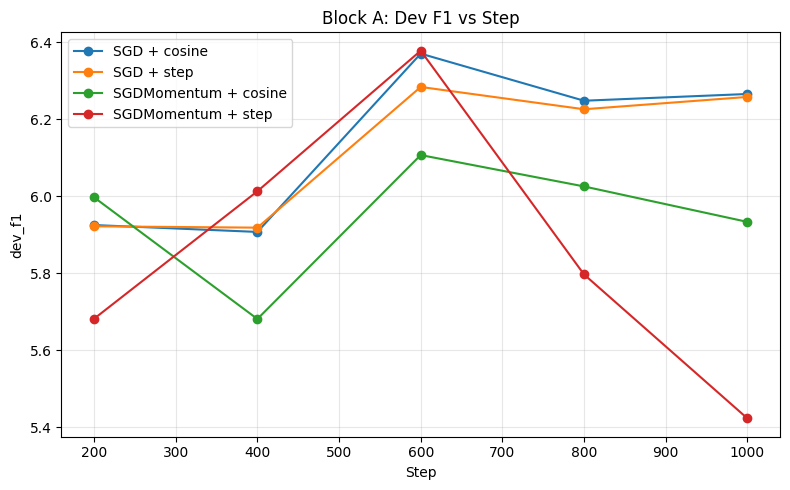

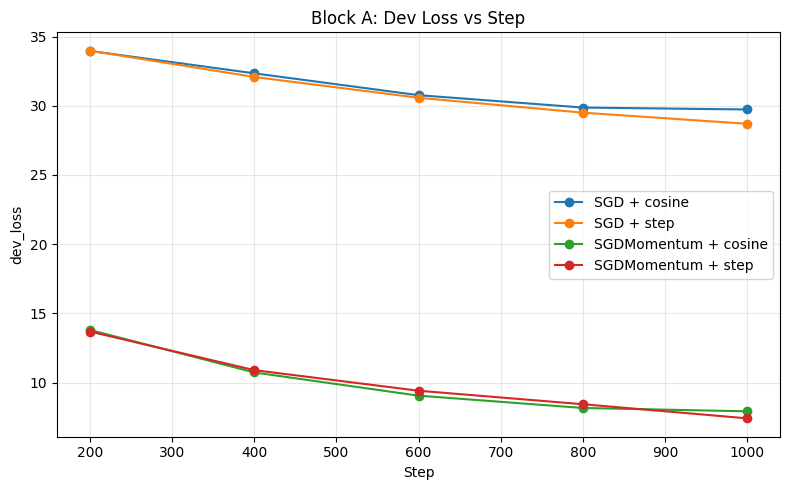

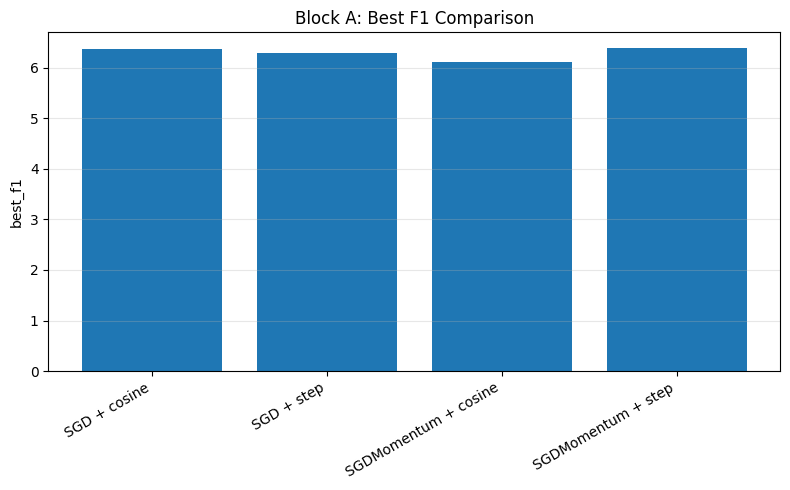

In [38]:
if "block_a_records" in globals():
    plot_metric_curves(block_a_records, "dev_f1", "Block A: Dev F1 vs Step")
    plot_metric_curves(block_a_records, "dev_loss", "Block A: Dev Loss vs Step")
    plot_best_scores(block_a_records, metric="best_f1", title="Block A: Best F1 Comparison")
else:
    print("`block_a_records` not found. Please run Block A first.")

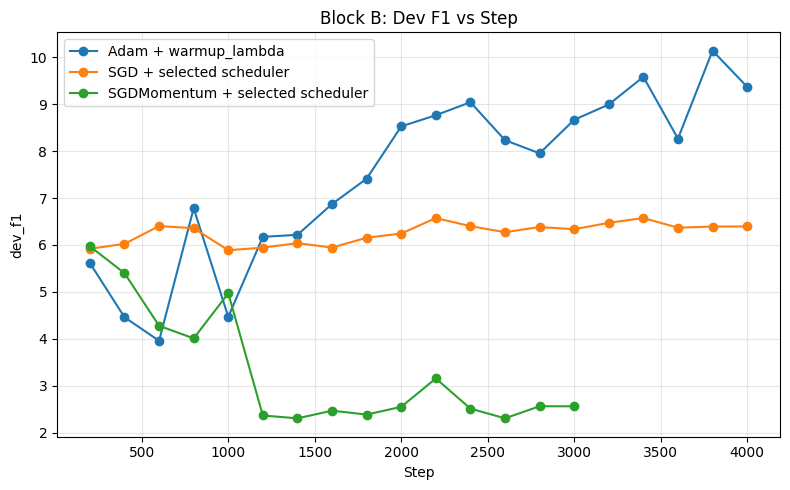

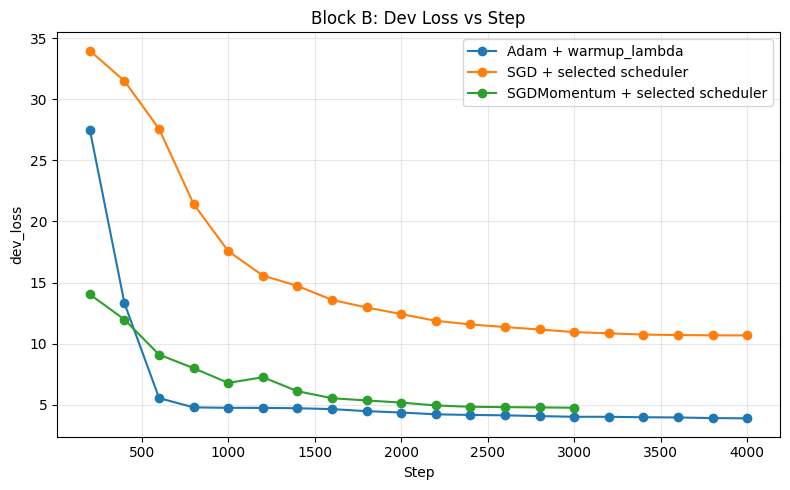

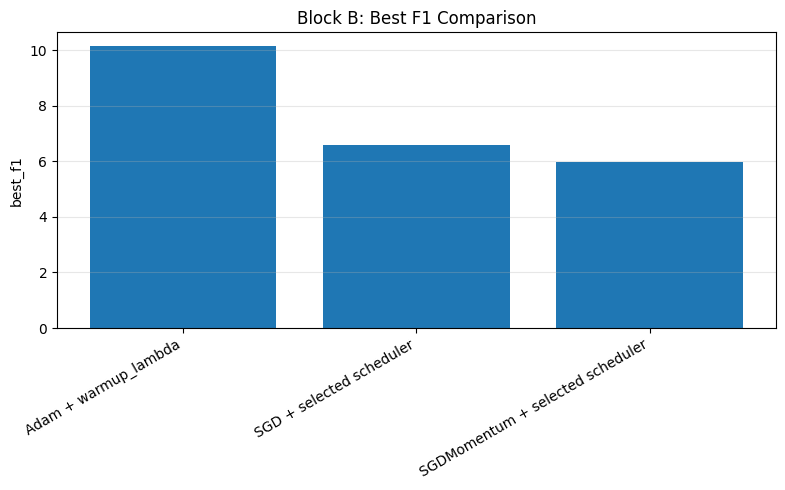

In [41]:
if "block_b_records" in globals():
    plot_metric_curves(block_b_records, "dev_f1", "Block B: Dev F1 vs Step")
    plot_metric_curves(block_b_records, "dev_loss", "Block B: Dev Loss vs Step")
    plot_best_scores(block_b_records, metric="best_f1", title="Block B: Best F1 Comparison")
else:
    print("`block_b_records` not found. Please run Block B first.")